In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv("/content/airpollution(dataset).csv")

df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12,1018.0,NW,12.97,0,0


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Shape: (15000, 13)

Columns:
Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      15000 non-null  int64  
 1   year    15000 non-null  int64  
 2   month   15000 non-null  int64  
 3   day     15000 non-null  int64  
 4   hour    15000 non-null  int64  
 5   pm2.5   13738 non-null  float64
 6   DEWP    15000 non-null  int64  
 7   TEMP    15000 non-null  int64  
 8   PRES    15000 non-null  float64
 9   cbwd    15000 non-null  object 
 10  Iws     15000 non-null  float64
 11  Is      15000 non-null  int64  
 12  Ir      15000 non-null  int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 1.5+ MB

Statistical Summary:


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,13738.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2010.41600,5.816000,15.531200,11.500000,98.493376,2.376533,12.937533,1015.480100,28.910369,0.066867,0.225800
std,4330.271354,0.49291,3.195063,8.779691,6.922417,89.476732,14.998996,12.620813,10.314908,56.072110,0.917198,1.582334
min,1.000000,2010.00000,1.000000,1.000000,0.000000,1.000000,-28.000000,-19.000000,993.000000,0.450000,0.000000,0.000000
25%,3750.750000,2010.00000,3.000000,8.000000,5.750000,31.000000,-11.000000,2.000000,1007.000000,1.790000,0.000000,0.000000
50%,7500.500000,2010.00000,6.000000,15.000000,11.500000,74.000000,3.000000,15.000000,1014.000000,7.150000,0.000000,0.000000
75%,11250.250000,2011.00000,8.000000,23.000000,17.250000,137.000000,17.000000,24.000000,1023.000000,27.720000,0.000000,0.000000
max,15000.000000,2011.00000,12.000000,31.000000,23.000000,980.000000,28.000000,41.000000,1045.000000,585.600000,27.000000,36.000000


In [4]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,1262
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [5]:
df = df.dropna(subset=["pm2.5"])

print("Shape after removing missing target values:", df.shape)

Shape after removing missing target values: (13738, 13)


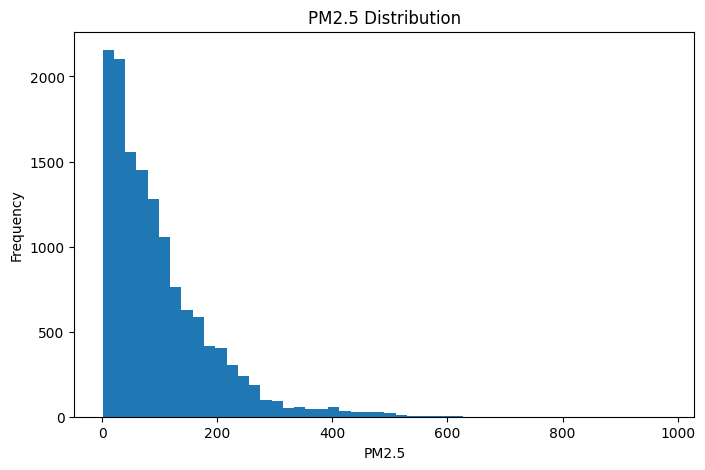

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["pm2.5"], bins=50)

plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("PM2.5 Distribution")

plt.show()

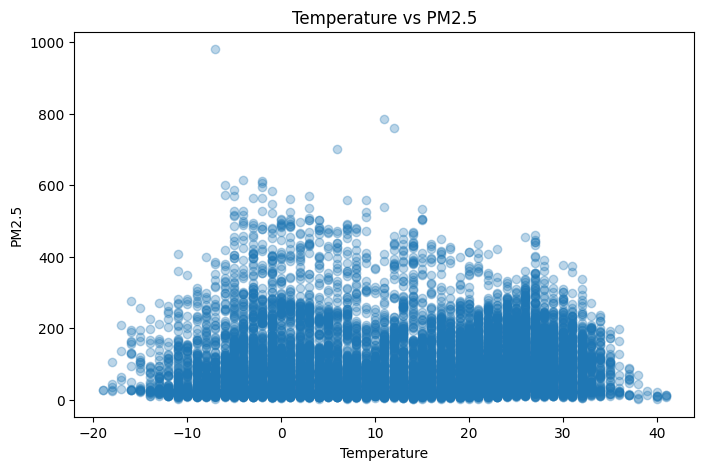

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(df["TEMP"], df["pm2.5"], alpha=0.3)

plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.title("Temperature vs PM2.5")

plt.show()

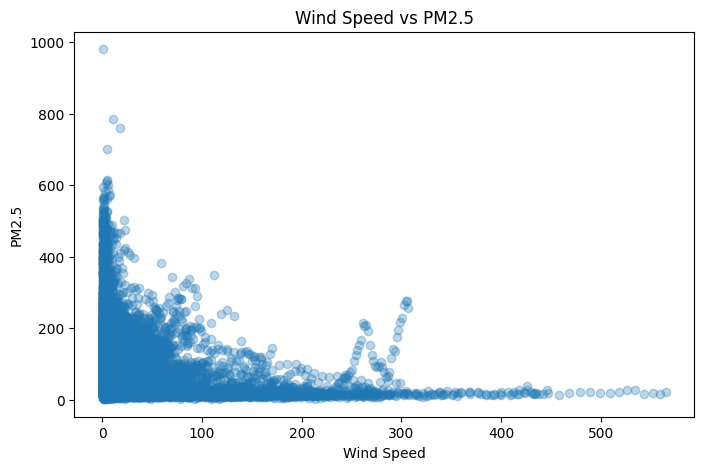

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(df["Iws"], df["pm2.5"], alpha=0.3)

plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.title("Wind Speed vs PM2.5")

plt.show()

In [9]:
X = df.drop(columns=["pm2.5", "No"])

y = df["pm2.5"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws',
       'Is', 'Ir'],
      dtype='object')

Target:
pm2.5


In [10]:
categorical_features = ["cbwd"]

numerical_features = [
    "year",
    "month",
    "day",
    "hour",
    "DEWP",
    "TEMP",
    "PRES",
    "Iws",
    "Is",
    "Ir"
]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10990, 11)
Testing data: (2748, 11)


In [12]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [13]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [14]:
linear_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [15]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [16]:
tree_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [17]:
rf_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [18]:
gb_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        loss="huber",
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [19]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return [name, mae, rmse, r2]

In [20]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,54.465820,76.829422,0.278675
1,Ridge Regression,54.464458,76.829481,0.278674
2,Decision Tree,32.232670,50.629901,0.686751
3,Random Forest,23.256719,37.260369,0.830344
4,Gradient Boosting,41.675959,61.719128,0.534505


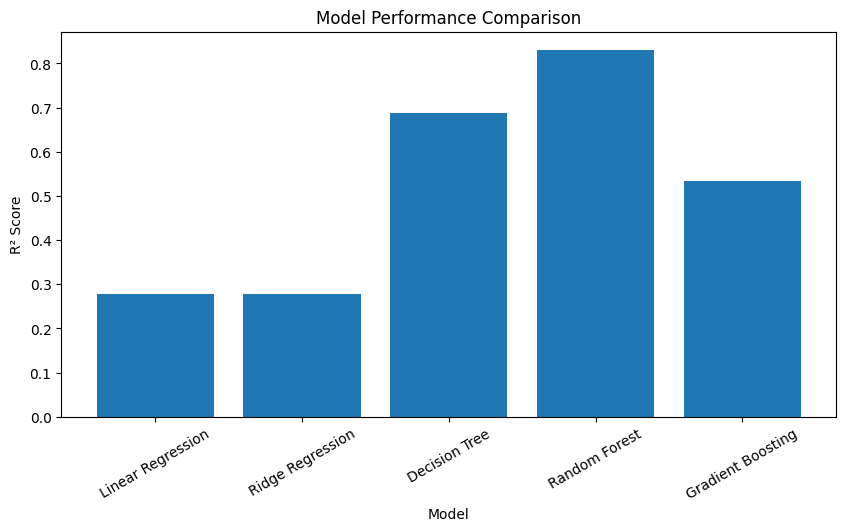

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=30)

plt.show()

In [22]:
model_dict = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

best_model = model_dict[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


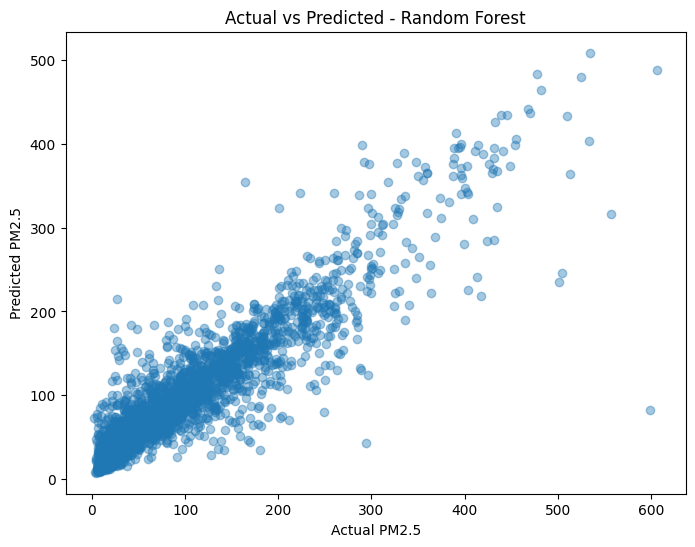

In [23]:
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.show()

In [24]:
rf = rf_model.named_steps["model"]

importances = rf.feature_importances_

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
4,num__DEWP,0.275965
2,num__day,0.179664
1,num__month,0.133925
6,num__PRES,0.121540
7,num__Iws,0.107180
5,num__TEMP,0.072056
3,num__hour,0.049956
12,cat__cbwd_SE,0.024434
0,num__year,0.020235
11,cat__cbwd_NW,0.005260


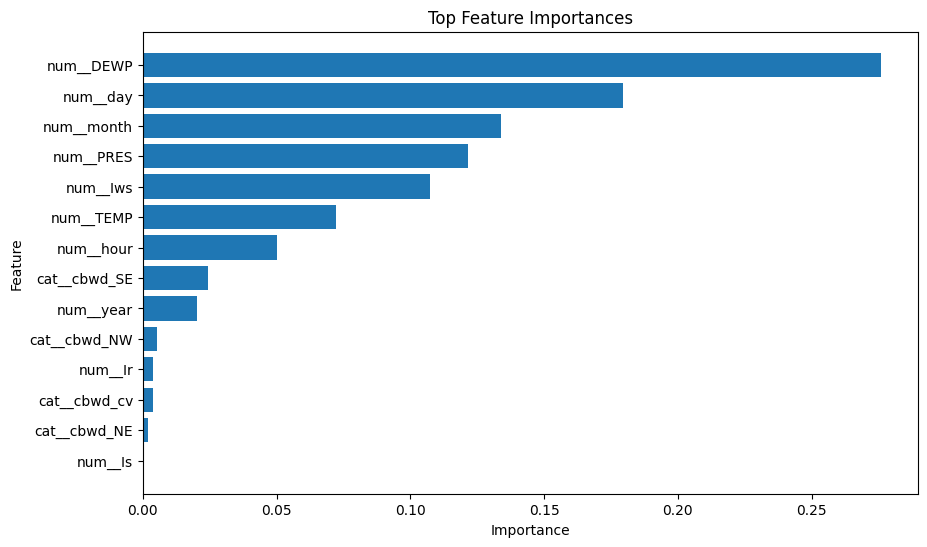

In [25]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances")

plt.show()

In [26]:
joblib.dump(
    best_model,
    "best_air_pollution_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [27]:
sample_data = pd.DataFrame({
    "year": [2011],
    "month": [5],
    "day": [15],
    "hour": [12],
    "DEWP": [10.0],
    "TEMP": [20.0],
    "PRES": [1015.0],
    "cbwd": ["NW"],
    "Iws": [5.0],
    "Is": [0.0],
    "Ir": [0.0]
})

sample_prediction = best_model.predict(sample_data)[0]

print(
    f"Predicted PM2.5: {sample_prediction:.2f}"
)

Predicted PM2.5: 105.66


In [28]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Air Pollution Predictor",
    page_icon="🌫️",
    layout="wide"
)

@st.cache_resource
def load_model():
    return joblib.load("best_air_pollution_model.pkl")

model = load_model()

st.title("🌫️ Air Pollution PM2.5 Prediction")

st.markdown(
    "Enter the weather and environmental conditions "
    "to predict PM2.5 pollution."
)

st.sidebar.header("🌦️ Weather & Environmental Information")

year = st.sidebar.number_input(
    "Year", 2000, 2030, 2011
)

month = st.sidebar.number_input(
    "Month", 1, 12, 5
)

day = st.sidebar.number_input(
    "Day", 1, 31, 15
)

hour = st.sidebar.number_input(
    "Hour", 0, 23, 12
)

dewp = st.sidebar.number_input(
    "Dew Point (DEWP)", value=10.0
)

temp = st.sidebar.number_input(
    "Temperature (TEMP)", value=20.0
)

pres = st.sidebar.number_input(
    "Pressure (PRES)", value=1015.0
)

cbwd = st.sidebar.selectbox(
    "Wind Direction",
    ["NW", "NE", "SE", "cv"]
)

iws = st.sidebar.number_input(
    "Wind Speed (Iws)",
    min_value=0.0,
    value=5.0
)

snow = st.sidebar.number_input(
    "Snow Hours (Is)",
    min_value=0.0,
    value=0.0
)

rain = st.sidebar.number_input(
    "Rain Hours (Ir)",
    min_value=0.0,
    value=0.0
)

st.divider()

st.subheader("🔮 PM2.5 Prediction")

if st.button(
    "🚀 Predict PM2.5",
    use_container_width=True
):

    input_data = pd.DataFrame({
        "year": [year],
        "month": [month],
        "day": [day],
        "hour": [hour],
        "DEWP": [dewp],
        "TEMP": [temp],
        "PRES": [pres],
        "cbwd": [cbwd],
        "Iws": [iws],
        "Is": [snow],
        "Ir": [rain]
    })

    prediction = model.predict(input_data)[0]

    st.success(
        f"🌫️ Predicted PM2.5: {prediction:.2f}"
    )

    if prediction < 50:
        st.info("🟢 Pollution Level: Low")

    elif prediction < 100:
        st.warning("🟡 Pollution Level: Moderate")

    elif prediction < 150:
        st.warning("🟠 Pollution Level: High")

    else:
        st.error("🔴 Pollution Level: Very High")

Writing app.py


In [29]:
!pip install -q streamlit

import subprocess
import time
from google.colab.output import eval_js

# Stop previous Streamlit server
!pkill -f streamlit

# Start Streamlit
subprocess.Popen([
    "streamlit",
    "run",
    "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

time.sleep(3)

url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("=" * 60)
print("🌫️ AIR POLLUTION STREAMLIT APP")
print("=" * 60)
print("👉 CLICK THIS LINK:")
print(url)
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 27.8 MB/s eta 0:00:00
🌫️ AIR POLLUTION STREAMLIT APP
👉 CLICK THIS LINK:
https://8501-m-s-kkb-use1d0-1xe68jboonlp8-d.us-east1-0.prod.colab.dev
